# Disruption Gate Stabilization for D-CQHGT Cold-OD

This notebook implements the stabilization experiment after the first disruption-gate run.

It completes five tasks:

1. Reproduce two strong no-disruption topology backbones:
   - `hgt_truck_rail_plus_topology_features`
   - `hgt_terminal_plus_truck_plus_rail`
2. Load the no-disruption checkpoint for each seed.
3. Freeze the HGT encoder and base decoder, then train only a disruption gate and a small decoder adapter.
4. Evaluate four disruption settings:
   - `no_disruption_reproduced`
   - `weather_zone_only`
   - `border_global_only`
   - `weather_zone_plus_border_global`
5. Produce strict Cold-OD test predictions with exactly one prediction per `row_id`, including deduplicated GraphV2 references with `n_rows = 1057`.

All Markdown explanations and code comments are in English for reproducibility and clean reporting.


## 1. Kernel preflight

This project must run in the CUDA/PyG environment. The base Anaconda kernel has shown NumPy ABI conflicts and does not have `torch_geometric`. This cell checks the current executable before importing heavy packages.


In [1]:

import os
import sys
import subprocess
from pathlib import Path

EXPECTED_PYTHON = Path(r"E:\NetworkOptimization\pythonProject1\env\.venv_freight_mnet_cuda\Scripts\python.exe")
CURRENT_PYTHON = Path(sys.executable)

print("Current Python executable:", CURRENT_PYTHON)
print("Expected CUDA/PyG executable:", EXPECTED_PYTHON)

if EXPECTED_PYTHON.exists() and CURRENT_PYTHON.resolve() != EXPECTED_PYTHON.resolve():
    print("The active Jupyter kernel is not the expected FREIGHT-MNet CUDA/PyG environment.")
    print("Attempting to register the correct kernel...")
    subprocess.run([str(EXPECTED_PYTHON), "-m", "pip", "install", "ipykernel"], check=False)
    subprocess.run([
        str(EXPECTED_PYTHON), "-m", "ipykernel", "install", "--user",
        "--name", "freight_mnet_cuda", "--display-name", "Python (freight_mnet_cuda)"
    ], check=False)
    raise RuntimeError("Switch the notebook kernel to Python (freight_mnet_cuda), then rerun from the top.")

print("Kernel preflight passed.")


Current Python executable: E:\NetworkOptimization\pythonProject1\env\.venv_freight_mnet_cuda\Scripts\python.exe
Expected CUDA/PyG executable: E:\NetworkOptimization\pythonProject1\env\.venv_freight_mnet_cuda\Scripts\python.exe
Kernel preflight passed.


## 2. Imports

The notebook disables optional pandas acceleration backends to avoid optional binary-extension problems in mixed NumPy environments. It requires PyTorch Geometric.


In [2]:

from __future__ import annotations

import json
import math
import os
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
pd.set_option("compute.use_numexpr", False)
pd.set_option("compute.use_bottleneck", False)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, TensorDataset

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv
except Exception as exc:
    raise ImportError("torch_geometric is required. Use the Python (freight_mnet_cuda) kernel.") from exc

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception:
    MATPLOTLIB_AVAILABLE = False

print("Python:", os.sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


Python: 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
NumPy: 2.4.5
Pandas: 2.3.3
Torch: 2.12.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU


## 3. Experiment configuration

The default run uses five seeds. For a fast smoke test, set `smoke_test=True`; the notebook will reduce seeds and epochs automatically.


In [3]:

@dataclass
class ExperimentConfig:
    data_root: Path = Path(r"E:\NetworkOptimization\pythonProject1\Data")
    scope: str = "east_plus_gulf"
    run_name: str = "dcqhgt_disruption_gate_stabilization_v1_notebook"
    expected_test_rows: int = 1057
    seeds: Tuple[int, ...] = (7, 42, 123, 2026, 535)
    smoke_test: bool = False

    hidden_dim: int = 128
    hgt_layers: int = 2
    hgt_heads: int = 4
    dropout: float = 0.10
    batch_size: int = 4096

    max_epochs_backbone: int = 300
    patience_backbone: int = 35
    max_epochs_adapter: int = 140
    patience_adapter: int = 25

    lr_backbone: float = 1.0e-3
    lr_adapter: float = 5.0e-4
    weight_decay: float = 1.0e-4
    grad_clip_norm: float = 5.0
    lambda_iqr: float = 0.10
    gate_alpha_init: float = 0.05

    sample_weight_column: str = "obs_weight_sum"
    weight_clip_min: float = 0.05
    weight_clip_max: float = 20.0
    target_scale_strategy: str = "train_q50_median"
    num_workers: int = 0
    save_models: bool = True
    overwrite: bool = True

cfg = ExperimentConfig()
if cfg.smoke_test:
    cfg.seeds = (42,)
    cfg.max_epochs_backbone = 20
    cfg.patience_backbone = 5
    cfg.max_epochs_adapter = 15
    cfg.patience_adapter = 4

print(cfg)


ExperimentConfig(data_root=WindowsPath('E:/NetworkOptimization/pythonProject1/Data'), scope='east_plus_gulf', run_name='dcqhgt_disruption_gate_stabilization_v1_notebook', expected_test_rows=1057, seeds=(7, 42, 123, 2026, 535), smoke_test=False, hidden_dim=128, hgt_layers=2, hgt_heads=4, dropout=0.1, batch_size=4096, max_epochs_backbone=300, patience_backbone=35, max_epochs_adapter=140, patience_adapter=25, lr_backbone=0.001, lr_adapter=0.0005, weight_decay=0.0001, grad_clip_norm=5.0, lambda_iqr=0.1, gate_alpha_init=0.05, sample_weight_column='obs_weight_sum', weight_clip_min=0.05, weight_clip_max=20.0, target_scale_strategy='train_q50_median', num_workers=0, save_models=True, overwrite=True)


## 4. Paths

The notebook reads the full HeteroData object, the disruption-augmented supervised table, the disruption QA table, and prior baseline predictions. It writes all outputs into a new stabilization experiment directory.


In [4]:

@dataclass
class ExperimentPaths:
    data_root: Path
    scope: str
    run_name: str

    @property
    def graph_inputs_dir(self) -> Path:
        return self.data_root / "08_processed" / "graph_inputs"

    @property
    def heterodata_path(self) -> Path:
        return self.graph_inputs_dir / f"freight_mnet_full_heterodata_{self.scope}.pt"

    @property
    def topology_features_path(self) -> Path:
        return self.graph_inputs_dir / f"topology_features_od_{self.scope}.parquet"

    @property
    def supervised_with_disruption_path(self) -> Path:
        return self.data_root / "08_processed" / "disruption_features" / f"freight_mnet_supervised_edges_2018_2024_{self.scope}_with_disruption.parquet"

    @property
    def disruption_qa_path(self) -> Path:
        return self.data_root / "10_experiments" / "build_disruption_features_od_year_v1" / self.scope / "tables" / "disruption_feature_qa_summary.csv"

    @property
    def cold_baseline_predictions_path(self) -> Path:
        return self.data_root / "10_experiments" / "cold_od_split_baselines_v1_notebook" / self.scope / "predictions_cold_od_val_test.parquet"

    @property
    def graphv2_predictions_path(self) -> Path:
        return self.data_root / "10_experiments" / "graphsage_hgt_cold_od_baselines_v2_notebook" / self.scope / "combined_predictions_graph_cold_od_val_test_v2.parquet"

    @property
    def output_dir(self) -> Path:
        return self.data_root / "10_experiments" / self.run_name / self.scope

paths = ExperimentPaths(cfg.data_root, cfg.scope, cfg.run_name)
output_dir = paths.output_dir
models_dir = output_dir / "models"
tables_dir = output_dir / "tables"
plots_dir = output_dir / "plots"
reports_dir = output_dir / "reports"
for directory in [output_dir, models_dir, tables_dir, plots_dir, reports_dir]:
    directory.mkdir(parents=True, exist_ok=True)
print("Output directory:", output_dir)


Output directory: E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_disruption_gate_stabilization_v1_notebook\east_plus_gulf


## 5. Utility functions

These helpers handle reproducibility, safe output writing, and plain-text reporting without requiring `tabulate`.


In [5]:

def ensure_file_exists(path: Path, description: str) -> None:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{description} not found: {path}")


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    return str(value)


def write_json(payload: dict, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=json_default)
    return path


FORCE_STRING_COLUMNS = {
    "source", "model", "topology_candidate", "disruption_group", "checkpoint_metric",
    "checkpoint", "seed", "split", "reference_name", "candidate_model", "row_id"
}


def normalize_dataframe_for_parquet(frame: pd.DataFrame) -> pd.DataFrame:
    clean = frame.copy()
    clean.columns = [str(c) for c in clean.columns]
    for column in clean.columns:
        s = clean[column]
        object_like = pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s) or str(s.dtype) == "category"
        if column in FORCE_STRING_COLUMNS or object_like:
            clean[column] = s.map(lambda x: pd.NA if pd.isna(x) else str(x)).astype("string")
    return clean


def safe_to_parquet(frame: pd.DataFrame, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    normalize_dataframe_for_parquet(frame).to_parquet(path, index=False, engine="pyarrow")
    return path


def print_frame(name: str, frame: pd.DataFrame, max_rows: int = 10) -> None:
    print(f"\n{name}: shape={frame.shape}")
    if not frame.empty:
        print(frame.head(max_rows).to_string(index=False))


def dataframe_to_text(frame: pd.DataFrame, columns: Sequence[str], max_rows: int = 15) -> str:
    if frame.empty:
        return "_No rows available._"
    cols = [c for c in columns if c in frame.columns]
    return frame[cols].head(max_rows).to_string(index=False)


## 6. Load artifacts

This cell loads the full hetero graph, the disruption-augmented supervised table, disruption QA summary, and topology feature table.


In [6]:

def load_heterodata(path: Path) -> HeteroData:
    ensure_file_exists(path, "Full HeteroData")
    try:
        data_obj = torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        data_obj = torch.load(path, map_location="cpu")
    if not isinstance(data_obj, HeteroData):
        raise TypeError(f"Expected HeteroData, got {type(data_obj)}")
    return data_obj

ensure_file_exists(paths.heterodata_path, "Full HeteroData")
ensure_file_exists(paths.supervised_with_disruption_path, "Supervised table with disruption features")
ensure_file_exists(paths.disruption_qa_path, "Disruption feature QA summary")
ensure_file_exists(paths.topology_features_path, "Topology features")

full_data = load_heterodata(paths.heterodata_path)
supervised_disruption_df = pd.read_parquet(paths.supervised_with_disruption_path)
disruption_qa = pd.read_csv(paths.disruption_qa_path)
topology_features_df = pd.read_parquet(paths.topology_features_path)

print(full_data)
print_frame("Supervised + disruption", supervised_disruption_df, max_rows=3)
print_frame("Disruption QA", disruption_qa, max_rows=5)


HeteroData(
  faf_zone={
    x=[132, 86],
    node_id=[132],
  },
  terminal={
    x=[241, 5],
    node_id=[241],
  },
  (faf_zone, truck_adj, faf_zone)={
    edge_index=[2, 582],
    edge_attr=[582, 3],
  },
  (faf_zone, rail_adj, faf_zone)={
    edge_index=[2, 510],
    edge_attr=[510, 3],
  },
  (faf_zone, demand_truck, faf_zone)={
    edge_index=[2, 8693],
    edge_attr=[8693, 4],
  },
  (faf_zone, rev_demand_truck, faf_zone)={
    edge_index=[2, 8693],
    edge_attr=[8693, 4],
  },
  (faf_zone, demand_rail, faf_zone)={
    edge_index=[2, 5834],
    edge_attr=[5834, 4],
  },
  (faf_zone, rev_demand_rail, faf_zone)={
    edge_index=[2, 5834],
    edge_attr=[5834, 4],
  },
  (faf_zone, demand_multimodal, faf_zone)={
    edge_index=[2, 8692],
    edge_attr=[8692, 4],
  },
  (faf_zone, rev_demand_multimodal, faf_zone)={
    edge_index=[2, 8692],
    edge_attr=[8692, 4],
  },
  (faf_zone, train_od, faf_zone)={
    edge_index=[2, 8748],
    edge_attr=[8748, 2],
  },
  (faf_zone, rev_trai

## 7. Extract supervised tensors

The supervised OD store contains labels, row IDs, masks, and edge-label features. This cell validates the Cold-OD test count.


In [7]:

SUPERVISED_EDGE_TYPE = ("faf_zone", "supervised_od", "faf_zone")
store = full_data[SUPERVISED_EDGE_TYPE]

edge_label_index_cpu = store.edge_label_index.long()
edge_label_attr_raw_cpu = store.edge_label_attr_raw.float() if "edge_label_attr_raw" in store.keys() else store.edge_label_attr.float()
y_cpu = store.y.float()
row_id_cpu = store.row_id.long()

cold_train_mask_cpu = store.cold_train_mask.bool()
cold_val_mask_cpu = store.cold_val_mask.bool()
cold_test_mask_cpu = store.cold_test_mask.bool()

split_counts = {
    "train": int(cold_train_mask_cpu.sum()),
    "val": int(cold_val_mask_cpu.sum()),
    "test": int(cold_test_mask_cpu.sum()),
}
print("Cold split counts:", split_counts)
if split_counts["test"] != cfg.expected_test_rows:
    raise ValueError(f"Expected {cfg.expected_test_rows} test rows, found {split_counts['test']}.")

if "row_id" not in supervised_disruption_df.columns:
    raise ValueError("The disruption-augmented supervised table must contain row_id.")

supervised_disruption_df = supervised_disruption_df.copy()
supervised_disruption_df["row_id"] = pd.to_numeric(supervised_disruption_df["row_id"], errors="raise").astype(int)
row_order = pd.DataFrame({"row_id": row_id_cpu.numpy().astype(int), "tensor_pos": np.arange(len(row_id_cpu))})
merged_rows = row_order.merge(supervised_disruption_df, on="row_id", how="left", validate="one_to_one")
if merged_rows.isna().all(axis=1).any():
    raise ValueError("Some HeteroData row_id values are missing in the disruption table.")
print("Aligned row table:", merged_rows.shape)


Cold split counts: {'train': 42849, 'val': 957, 'test': 1057}
Aligned row table: (73972, 220)


## 8. Prune disruption features and define groups

The notebook keeps variable disruption features while excluding QA-only and constant columns. It runs four groups: no disruption, weather zone only, border global only, and weather zone + border global.


In [8]:

QA_EXCLUDE_PATTERNS = ["source_file_count", "source_missing", "feature_available", "duration_hours"]


def first_existing(columns: Sequence[str], candidates: Sequence[str]) -> Optional[str]:
    for c in candidates:
        if c in columns:
            return c
    return None


def select_variable_disruption_features(qa_frame: pd.DataFrame, available_columns: Sequence[str]) -> Dict[str, List[str]]:
    if "feature" not in qa_frame.columns:
        raise ValueError("disruption QA summary must contain a feature column.")
    std_col = first_existing(qa_frame.columns, ["std", "std_value", "standard_deviation"])
    nonzero_col = first_existing(qa_frame.columns, ["nonzero_rate", "non_zero_rate"])
    available = set(available_columns)
    groups = {"weather_zone": [], "weather_global": [], "border_global": [], "rail_global": []}
    for _, row in qa_frame.iterrows():
        feature = str(row["feature"])
        if feature not in available or not feature.startswith("disrupt_"):
            continue
        if any(pattern in feature for pattern in QA_EXCLUDE_PATTERNS):
            continue
        if std_col is not None:
            try:
                if float(row[std_col]) <= 0.0:
                    continue
            except Exception:
                pass
        if nonzero_col is not None:
            try:
                if float(row[nonzero_col]) <= 0.0:
                    continue
            except Exception:
                pass
        if "weather_global" in feature:
            groups["weather_global"].append(feature)
        elif "weather" in feature:
            groups["weather_zone"].append(feature)
        elif "border_global" in feature:
            groups["border_global"].append(feature)
        elif "rail_global" in feature:
            groups["rail_global"].append(feature)
    return {k: sorted(v) for k, v in groups.items()}

feature_groups = select_variable_disruption_features(disruption_qa, merged_rows.columns)
experiment_groups = {
    "no_disruption_reproduced": [],
    "weather_zone_only": feature_groups["weather_zone"],
    "border_global_only": feature_groups["border_global"],
    "weather_zone_plus_border_global": feature_groups["weather_zone"] + feature_groups["border_global"],
}

feature_group_summary = pd.DataFrame([
    {"group": k, "n_features": len(v), "preview": ", ".join(v[:6])}
    for k, v in experiment_groups.items()
])
print_frame("Disruption groups", feature_group_summary)
write_json({"feature_groups": feature_groups, "experiment_groups": experiment_groups}, output_dir / "disruption_gate_stabilization_feature_groups.json")
feature_group_summary.to_csv(tables_dir / "disruption_gate_stabilization_feature_group_summary.csv", index=False)



Disruption groups: shape=(4, 3)
                          group  n_features                                                                                                                                                                                                                                                                                       preview
       no_disruption_reproduced           0                                                                                                                                                                                                                                                                                              
              weather_zone_only          60                                                 disrupt_absdiff_weather_convective_count, disrupt_absdiff_weather_damage_total_usd, disrupt_absdiff_weather_event_count, disrupt_absdiff_weather_fatality_count, disrupt_absdiff_weather_flood_count, disrupt_absdiff_w

## 9. Fallback prior and sample weights

Cold-OD validation and test OD pairs have no exact OD history. The residual head therefore uses a train-only origin/destination fallback prior.


In [9]:

LABEL_COLUMNS = ["truck_q25", "truck_q50", "truck_q75"]
TAUS = torch.tensor([0.25, 0.50, 0.75], dtype=torch.float32)


def normalize_faf_code(value: object) -> str:
    if pd.isna(value):
        return ""
    digits = "".join(ch for ch in str(value) if ch.isdigit())
    return digits[-3:].zfill(3) if digits else str(value)


def find_column(columns: Sequence[str], candidates: Sequence[str]) -> Optional[str]:
    for c in candidates:
        if c in columns:
            return c
    return None

orig_col = find_column(merged_rows.columns, ["faf_orig_str", "faf_orig", "origin_faf", "orig_faf"])
dest_col = find_column(merged_rows.columns, ["faf_dest_str", "faf_dest", "destination_faf", "dest_faf"])
if orig_col is None or dest_col is None:
    raise ValueError("Could not find FAF origin/destination columns.")

prior_df = pd.DataFrame({
    "row_id": row_id_cpu.numpy().astype(int),
    "origin": merged_rows[orig_col].map(normalize_faf_code).astype(str),
    "destination": merged_rows[dest_col].map(normalize_faf_code).astype(str),
    "is_train": cold_train_mask_cpu.numpy().astype(bool),
})
for j, label in enumerate(LABEL_COLUMNS):
    prior_df[label] = y_cpu[:, j].numpy()

train_prior_df = prior_df.loc[prior_df["is_train"]].copy()
global_prior = train_prior_df[LABEL_COLUMNS].median().to_numpy(np.float32)
origin_prior_table = train_prior_df.groupby("origin")[LABEL_COLUMNS].median()
dest_prior_table = train_prior_df.groupby("destination")[LABEL_COLUMNS].median()


def blended_zone_prior(row: pd.Series) -> np.ndarray:
    pieces = []
    if row["origin"] in origin_prior_table.index:
        pieces.append(origin_prior_table.loc[row["origin"]].to_numpy(np.float32))
    if row["destination"] in dest_prior_table.index:
        pieces.append(dest_prior_table.loc[row["destination"]].to_numpy(np.float32))
    if not pieces:
        return global_prior.copy()
    return np.mean(np.stack(pieces), axis=0).astype(np.float32)

base_prior_np = np.vstack([blended_zone_prior(row) for _, row in prior_df.iterrows()]).astype(np.float32)
base_prior_cpu = torch.from_numpy(base_prior_np)

target_scale = float(np.median(y_cpu[cold_train_mask_cpu, 1].numpy()))
print("Target scale:", target_scale)

if cfg.sample_weight_column in merged_rows.columns:
    raw_weight = pd.to_numeric(merged_rows[cfg.sample_weight_column], errors="coerce").fillna(0.0).to_numpy(np.float32)
    sample_weight = np.log1p(np.maximum(raw_weight, 0.0))
else:
    sample_weight = np.ones(len(merged_rows), dtype=np.float32)

sample_weight = np.clip(sample_weight, cfg.weight_clip_min, cfg.weight_clip_max)
sample_weight = sample_weight / max(float(sample_weight[cold_train_mask_cpu.numpy()].mean()), 1e-6)
sample_weight_cpu = torch.from_numpy(sample_weight.astype(np.float32))
print("Base prior shape:", base_prior_cpu.shape)
print("Sample weight summary:\n", pd.Series(sample_weight).describe().to_string())


Target scale: 2317.030029296875
Base prior shape: torch.Size([73972, 3])
Sample weight summary:
 count    73972.000000
mean         0.994823
std          0.335855
min          0.124688
25%          0.756226
50%          0.996517
75%          1.236499
max          2.100173


## 10. Edge feature preprocessing

The first 64 dimensions are current OD features. The remaining dimensions are topology/path features. Candidate A uses full edge features, while Candidate B uses base features only.


In [10]:

BASE_EDGE_DIM = 64
TOTAL_EDGE_DIM = int(edge_label_attr_raw_cpu.shape[1])
if TOTAL_EDGE_DIM < BASE_EDGE_DIM:
    raise ValueError(f"Expected at least {BASE_EDGE_DIM} edge features, got {TOTAL_EDGE_DIM}.")

base_edge_features_np = edge_label_attr_raw_cpu[:, :BASE_EDGE_DIM].numpy().astype(np.float32)
full_edge_features_np = edge_label_attr_raw_cpu.numpy().astype(np.float32)
train_mask_np = cold_train_mask_cpu.numpy().astype(bool)


def fit_numeric_preprocessor(values: np.ndarray, train_mask: np.ndarray) -> Dict[str, np.ndarray]:
    train_values = values[train_mask]
    median = np.nanmedian(train_values, axis=0)
    median = np.where(np.isfinite(median), median, 0.0)
    filled_train = np.where(np.isfinite(train_values), train_values, median)
    mean = filled_train.mean(axis=0)
    std = filled_train.std(axis=0)
    std = np.where(std > 1e-6, std, 1.0)
    return {"median": median.astype(np.float32), "mean": mean.astype(np.float32), "std": std.astype(np.float32)}


def transform_numeric(values: np.ndarray, preprocessor: Dict[str, np.ndarray]) -> np.ndarray:
    filled = np.where(np.isfinite(values), values, preprocessor["median"])
    return ((filled - preprocessor["mean"]) / preprocessor["std"]).astype(np.float32)

edge_preprocessor_base = fit_numeric_preprocessor(base_edge_features_np, train_mask_np)
edge_preprocessor_full = fit_numeric_preprocessor(full_edge_features_np, train_mask_np)
base_edge_scaled_cpu = torch.from_numpy(transform_numeric(base_edge_features_np, edge_preprocessor_base))
full_edge_scaled_cpu = torch.from_numpy(transform_numeric(full_edge_features_np, edge_preprocessor_full))

# Fit disruption preprocessors per group.
disruption_scaled_by_group: Dict[str, torch.Tensor] = {}
disruption_preprocessors: Dict[str, dict] = {}
for group_name, columns in experiment_groups.items():
    if not columns:
        raw = np.zeros((len(merged_rows), 0), dtype=np.float32)
        scaled = raw
        preproc = {"columns": [], "median": [], "mean": [], "std": []}
    else:
        raw = merged_rows[columns].apply(pd.to_numeric, errors="coerce").to_numpy(np.float32)
        fitted = fit_numeric_preprocessor(raw, train_mask_np)
        scaled = transform_numeric(raw, fitted)
        preproc = {k: v.tolist() for k, v in fitted.items()}
        preproc["columns"] = list(columns)
    disruption_scaled_by_group[group_name] = torch.from_numpy(scaled.astype(np.float32))
    disruption_preprocessors[group_name] = preproc

print("Base edge scaled:", base_edge_scaled_cpu.shape)
print("Full edge scaled:", full_edge_scaled_cpu.shape)
for group_name, tensor in disruption_scaled_by_group.items():
    print(group_name, tensor.shape)


Base edge scaled: torch.Size([73972, 64])
Full edge scaled: torch.Size([73972, 80])
no_disruption_reproduced torch.Size([73972, 0])
weather_zone_only torch.Size([73972, 60])
border_global_only torch.Size([73972, 6])
weather_zone_plus_border_global torch.Size([73972, 66])


## 11. Edge subsets and bidirectional topology repair

The truck and rail topology relations are made bidirectional in-place before training. Candidate A uses truck/rail topology + topology features. Candidate B uses terminal + truck/rail topology with base edge features.


In [11]:

def edge_storage_has(data: HeteroData, edge_type: Tuple[str, str, str], key: str) -> bool:
    return edge_type in data.edge_types and key in data[edge_type].keys()


def make_edge_index_bidirectional(edge_index: torch.Tensor) -> torch.Tensor:
    if edge_index.numel() == 0:
        return edge_index.long()
    reverse = torch.stack([edge_index[1].long(), edge_index[0].long()], dim=0)
    both = torch.cat([edge_index.long(), reverse], dim=1)
    unique_pairs = torch.unique(both.t(), dim=0)
    return unique_pairs.t().contiguous()


def bidirectional_ratio(edge_index: torch.Tensor) -> float:
    pairs = set(map(tuple, edge_index.t().cpu().numpy().tolist()))
    if not pairs:
        return 1.0
    reverse = {(j, i) for i, j in pairs}
    return len(pairs & reverse) / len(pairs)

repair_rows = []
for rel in ["truck_adj", "rail_adj"]:
    etype = ("faf_zone", rel, "faf_zone")
    if edge_storage_has(full_data, etype, "edge_index"):
        before = full_data[etype].edge_index.long()
        after = make_edge_index_bidirectional(before)
        full_data[etype].edge_index = after
        repair_rows.append({
            "relation": rel,
            "before_edges": int(before.shape[1]),
            "after_edges": int(after.shape[1]),
            "before_bidirectional_ratio": bidirectional_ratio(before),
            "after_bidirectional_ratio": bidirectional_ratio(after),
        })
repair_report = pd.DataFrame(repair_rows)
print_frame("Topology bidirectional repair", repair_report)
repair_report.to_csv(tables_dir / "disruption_gate_topology_bidirectional_repair_report.csv", index=False)

BASE_FAF_RELATIONS = [
    ("faf_zone", "demand_truck", "faf_zone"),
    ("faf_zone", "rev_demand_truck", "faf_zone"),
    ("faf_zone", "demand_rail", "faf_zone"),
    ("faf_zone", "rev_demand_rail", "faf_zone"),
    ("faf_zone", "demand_multimodal", "faf_zone"),
    ("faf_zone", "rev_demand_multimodal", "faf_zone"),
    ("faf_zone", "train_od", "faf_zone"),
    ("faf_zone", "rev_train_od", "faf_zone"),
    ("faf_zone", "self_loop", "faf_zone"),
]
TRUCK_RAIL_RELATIONS = [("faf_zone", "truck_adj", "faf_zone"), ("faf_zone", "rail_adj", "faf_zone")]
TERMINAL_RELATIONS = [("faf_zone", "terminal_access", "terminal"), ("terminal", "reverse_terminal_access", "faf_zone")]

TOPOLOGY_CANDIDATES = {
    "hgt_truck_rail_plus_topology_features": {
        "relations": BASE_FAF_RELATIONS + TRUCK_RAIL_RELATIONS,
        "use_terminals": False,
        "edge_feature_mode": "full",
    },
    "hgt_terminal_plus_truck_plus_rail": {
        "relations": BASE_FAF_RELATIONS + TRUCK_RAIL_RELATIONS + TERMINAL_RELATIONS,
        "use_terminals": True,
        "edge_feature_mode": "base",
    },
}


def build_edge_index_dict(data: HeteroData, relations: Sequence[Tuple[str, str, str]]) -> Dict[Tuple[str, str, str], torch.Tensor]:
    out = {}
    for etype in relations:
        if edge_storage_has(data, etype, "edge_index"):
            out[etype] = data[etype].edge_index.long()
        else:
            print("Warning: missing relation", etype)
    return out

for name, spec in TOPOLOGY_CANDIDATES.items():
    edge_dict = build_edge_index_dict(full_data, spec["relations"])
    print(name, len(edge_dict), "relations")
    for etype, edge_index in edge_dict.items():
        print(" ", etype, tuple(edge_index.shape))



Topology bidirectional repair: shape=(2, 5)
 relation  before_edges  after_edges  before_bidirectional_ratio  after_bidirectional_ratio
truck_adj           582          582                         1.0                        1.0
 rail_adj           510          510                         1.0                        1.0
hgt_truck_rail_plus_topology_features 11 relations
  ('faf_zone', 'demand_truck', 'faf_zone') (2, 8693)
  ('faf_zone', 'rev_demand_truck', 'faf_zone') (2, 8693)
  ('faf_zone', 'demand_rail', 'faf_zone') (2, 5834)
  ('faf_zone', 'rev_demand_rail', 'faf_zone') (2, 5834)
  ('faf_zone', 'demand_multimodal', 'faf_zone') (2, 8692)
  ('faf_zone', 'rev_demand_multimodal', 'faf_zone') (2, 8692)
  ('faf_zone', 'train_od', 'faf_zone') (2, 8748)
  ('faf_zone', 'rev_train_od', 'faf_zone') (2, 8748)
  ('faf_zone', 'self_loop', 'faf_zone') (2, 132)
  ('faf_zone', 'truck_adj', 'faf_zone') (2, 582)
  ('faf_zone', 'rail_adj', 'faf_zone') (2, 510)
hgt_terminal_plus_truck_plus_rail 13 relat

## 12. Loss and metric functions

The model trains on scaled minutes and uses a monotone residual quantile head.


In [12]:

def inv_softplus(x: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    x = torch.clamp(x, min=eps)
    return torch.where(x > 20.0, x, torch.log(torch.expm1(x)))


def residual_monotone_quantiles(raw: torch.Tensor, base_prior_scaled: torch.Tensor) -> torch.Tensor:
    base_q25 = torch.clamp(base_prior_scaled[:, 0], min=1e-4)
    base_gap50 = torch.clamp(base_prior_scaled[:, 1] - base_prior_scaled[:, 0], min=1e-4)
    base_gap75 = torch.clamp(base_prior_scaled[:, 2] - base_prior_scaled[:, 1], min=1e-4)
    q25 = F.softplus(inv_softplus(base_q25) + raw[:, 0])
    gap50 = F.softplus(inv_softplus(base_gap50) + raw[:, 1])
    gap75 = F.softplus(inv_softplus(base_gap75) + raw[:, 2])
    q50 = q25 + gap50
    q75 = q50 + gap75
    return torch.stack([q25, q50, q75], dim=-1)


def pinball_loss_per_row(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    taus = TAUS.to(pred.device).view(1, 3)
    diff = target - pred
    loss = torch.maximum(taus * diff, (taus - 1.0) * diff)
    return loss.mean(dim=1)


def training_loss(pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    q_loss = pinball_loss_per_row(pred, target)
    weighted = (q_loss * weight).mean()
    iqr_loss = F.smooth_l1_loss(pred[:, 2] - pred[:, 0], target[:, 2] - target[:, 0])
    return weighted + cfg.lambda_iqr * iqr_loss


def compute_metrics_from_arrays(true: np.ndarray, pred: np.ndarray, weights: Optional[np.ndarray] = None) -> Dict[str, float]:
    true = np.asarray(true, dtype=float)
    pred = np.asarray(pred, dtype=float)
    abs_err = np.abs(pred - true)
    out = {
        "mae_q25": float(abs_err[:, 0].mean()),
        "mae_q50": float(abs_err[:, 1].mean()),
        "mae_q75": float(abs_err[:, 2].mean()),
        "rmse_q50": float(np.sqrt(np.mean((pred[:, 1] - true[:, 1]) ** 2))),
    }
    true_iqr = true[:, 2] - true[:, 0]
    pred_iqr = pred[:, 2] - pred[:, 0]
    out["iqr_mae"] = float(np.mean(np.abs(pred_iqr - true_iqr)))
    pinball_cols = []
    for idx, tau in enumerate([0.25, 0.50, 0.75]):
        diff = true[:, idx] - pred[:, idx]
        loss = np.maximum(tau * diff, (tau - 1.0) * diff)
        out[f"pinball_q{int(tau * 100)}"] = float(loss.mean())
        pinball_cols.append(loss)
    row_pinball = np.mean(np.vstack(pinball_cols).T, axis=1)
    out["pinball_mean"] = float(row_pinball.mean())
    out["weighted_pinball_mean"] = float(np.average(row_pinball, weights=weights)) if weights is not None else out["pinball_mean"]
    q75_threshold = np.quantile(true[:, 2], 0.90)
    iqr_threshold = np.quantile(true_iqr, 0.90)
    out["stress_top10_mae_q75"] = float(abs_err[true[:, 2] >= q75_threshold, 2].mean())
    top_iqr = true_iqr >= iqr_threshold
    out["top_iqr10_mae_q75"] = float(abs_err[top_iqr, 2].mean())
    out["top_iqr10_iqr_mae"] = float(np.abs(pred_iqr[top_iqr] - true_iqr[top_iqr]).mean())
    out["raw_crossing_rate"] = float(np.mean((pred[:, 0] > pred[:, 1]) | (pred[:, 1] > pred[:, 2])))
    return out


## 13. Model definitions

`StabilizedDCQHGT` supports both no-disruption training and frozen adapter training. In adapter mode, only `disrupt_mlp`, `adapter_mlp`, and `gate_alpha` are trainable.


In [13]:

class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim), nn.GELU()
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class StabilizedDCQHGT(nn.Module):
    def __init__(self, metadata, node_input_dims, edge_feature_dim, disruption_dim, hidden_dim, heads, layers, dropout, gate_alpha_init):
        super().__init__()
        self.disruption_dim = int(disruption_dim)
        self.node_proj = nn.ModuleDict({ntype: nn.Linear(dim, hidden_dim) for ntype, dim in node_input_dims.items()})
        self.convs = nn.ModuleList([HGTConv(hidden_dim, hidden_dim, metadata, heads=heads) for _ in range(layers)])
        self.edge_mlp = MLP(edge_feature_dim, hidden_dim, hidden_dim, dropout)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 5, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU()
        )
        self.out = nn.Linear(hidden_dim, 3)
        if self.disruption_dim > 0:
            self.disrupt_mlp = MLP(disruption_dim, hidden_dim, hidden_dim, dropout)
            self.adapter_mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
            self.gate_alpha = nn.Parameter(torch.tensor(float(gate_alpha_init), dtype=torch.float32))
        else:
            self.disrupt_mlp = None
            self.adapter_mlp = None
            self.gate_alpha = None

    def encode_nodes(self, x_dict, edge_index_dict):
        h_dict = {ntype: F.gelu(self.node_proj[ntype](x)) for ntype, x in x_dict.items() if ntype in self.node_proj}
        for conv in self.convs:
            h_dict = conv(h_dict, edge_index_dict)
            h_dict = {k: F.gelu(v) for k, v in h_dict.items()}
        return h_dict

    def forward(self, x_dict, edge_index_dict, edge_label_index, edge_attr, base_prior_scaled, disruption_attr=None):
        h = self.encode_nodes(x_dict, edge_index_dict)
        src, dst = edge_label_index
        u = h["faf_zone"][src]
        v = h["faf_zone"][dst]
        e = self.edge_mlp(edge_attr)
        hidden = self.decoder(torch.cat([u, v, torch.abs(u - v), u * v, e], dim=-1))
        if self.disruption_dim > 0 and disruption_attr is not None and disruption_attr.shape[1] > 0:
            gate_hidden = self.disrupt_mlp(disruption_attr)
            gate = torch.sigmoid(gate_hidden)
            adapter = self.adapter_mlp(gate_hidden)
            hidden = hidden * (1.0 + self.gate_alpha * gate) + self.gate_alpha * adapter
        raw = self.out(hidden)
        return residual_monotone_quantiles(raw, base_prior_scaled)


def freeze_for_adapter_training(model: StabilizedDCQHGT) -> None:
    for _, p in model.named_parameters():
        p.requires_grad = False
    for name, p in model.named_parameters():
        if name.startswith("disrupt_mlp") or name.startswith("adapter_mlp") or name == "gate_alpha":
            p.requires_grad = True


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 14. Training utilities

The no-disruption model is trained first. Adapter models then load the checkpoint and train only the gate and small adapter.


In [14]:

def make_device_tensors(candidate_name: str, group_name: str, device: torch.device) -> dict:
    candidate = TOPOLOGY_CANDIDATES[candidate_name]
    edge_features = full_edge_scaled_cpu if candidate["edge_feature_mode"] == "full" else base_edge_scaled_cpu
    x_dict = {"faf_zone": full_data["faf_zone"].x.float().to(device)}
    if candidate["use_terminals"]:
        x_dict["terminal"] = full_data["terminal"].x.float().to(device)
    edge_index_cpu = build_edge_index_dict(full_data, candidate["relations"])
    return {
        "x_dict": x_dict,
        "edge_index_dict": {k: v.to(device) for k, v in edge_index_cpu.items()},
        "metadata": (list(x_dict.keys()), list(edge_index_cpu.keys())),
        "node_input_dims": {k: int(v.shape[1]) for k, v in x_dict.items()},
        "edge_label_index": edge_label_index_cpu.to(device),
        "edge_attr": edge_features.to(device),
        "disruption_attr": disruption_scaled_by_group[group_name].float().to(device),
        "base_prior_scaled": (base_prior_cpu / target_scale).float().to(device),
        "y_scaled": (y_cpu / target_scale).float().to(device),
        "weights": sample_weight_cpu.float().to(device),
    }


def make_loader(mask: torch.Tensor, batch_size: int, shuffle: bool, seed: int) -> DataLoader:
    idx = torch.where(mask)[0].long()
    gen = torch.Generator().manual_seed(seed)
    return DataLoader(TensorDataset(idx), batch_size=batch_size, shuffle=shuffle, generator=gen, num_workers=cfg.num_workers)


def run_epoch(model, tensors, loader, optimizer=None) -> float:
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_rows = 0.0, 0
    for (idx,) in loader:
        idx = idx.to(tensors["y_scaled"].device)
        pred = model(
            tensors["x_dict"], tensors["edge_index_dict"], tensors["edge_label_index"][:, idx],
            tensors["edge_attr"][idx], tensors["base_prior_scaled"][idx],
            tensors["disruption_attr"][idx] if tensors["disruption_attr"].shape[1] > 0 else None,
        )
        loss = training_loss(pred, tensors["y_scaled"][idx], tensors["weights"][idx])
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            optimizer.step()
        total_loss += float(loss.detach().cpu()) * int(idx.numel())
        total_rows += int(idx.numel())
    return total_loss / max(total_rows, 1)


@torch.no_grad()
def predict_for_mask(model, tensors, mask: torch.Tensor, batch_size: int):
    model.eval()
    device = tensors["y_scaled"].device
    idx_all = torch.where(mask)[0].long()
    loader = DataLoader(TensorDataset(idx_all), batch_size=batch_size, shuffle=False, num_workers=0)
    preds, trues, rows, weights = [], [], [], []
    for (idx,) in loader:
        idx = idx.to(device)
        pred_scaled = model(
            tensors["x_dict"], tensors["edge_index_dict"], tensors["edge_label_index"][:, idx],
            tensors["edge_attr"][idx], tensors["base_prior_scaled"][idx],
            tensors["disruption_attr"][idx] if tensors["disruption_attr"].shape[1] > 0 else None,
        )
        preds.append((pred_scaled.cpu().numpy() * target_scale).astype(np.float32))
        trues.append(y_cpu[idx.cpu()].numpy().astype(np.float32))
        rows.append(row_id_cpu[idx.cpu()].numpy().astype(int))
        weights.append(sample_weight_cpu[idx.cpu()].numpy().astype(np.float32))
    return np.vstack(trues), np.vstack(preds), np.concatenate(rows), np.concatenate(weights)


def train_model(candidate_name: str, group_name: str, seed: int, base_checkpoint_path: Optional[Path], adapter_mode: bool):
    set_global_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tensors = make_device_tensors(candidate_name, group_name, device)
    model = StabilizedDCQHGT(
        metadata=tensors["metadata"],
        node_input_dims=tensors["node_input_dims"],
        edge_feature_dim=int(tensors["edge_attr"].shape[1]),
        disruption_dim=int(tensors["disruption_attr"].shape[1]),
        hidden_dim=cfg.hidden_dim,
        heads=cfg.hgt_heads,
        layers=cfg.hgt_layers,
        dropout=cfg.dropout,
        gate_alpha_init=cfg.gate_alpha_init,
    ).to(device)
    if base_checkpoint_path is not None:
        ckpt = torch.load(base_checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if adapter_mode:
        freeze_for_adapter_training(model)
        max_epochs, patience, lr = cfg.max_epochs_adapter, cfg.patience_adapter, cfg.lr_adapter
    else:
        max_epochs, patience, lr = cfg.max_epochs_backbone, cfg.patience_backbone, cfg.lr_backbone
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=cfg.weight_decay)
    train_loader = make_loader(cold_train_mask_cpu, cfg.batch_size, True, seed)
    val_loader = make_loader(cold_val_mask_cpu, cfg.batch_size, False, seed)
    best_state, best_val, best_epoch, wait = None, math.inf, -1, 0
    history, start = [], time.time()
    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(model, tensors, train_loader, optimizer)
        val_loss = run_epoch(model, tensors, val_loader, None)
        history.append({"candidate": candidate_name, "disruption_group": group_name, "seed": seed, "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "adapter_mode": adapter_mode})
        if val_loss < best_val - 1e-6:
            best_val, best_epoch, wait = val_loss, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if wait >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    summary = {"candidate": candidate_name, "disruption_group": group_name, "seed": seed, "best_epoch": best_epoch, "best_val_loss_scaled": best_val, "elapsed_seconds": time.time() - start, "adapter_mode": adapter_mode, "trainable_parameters": count_trainable_parameters(model)}
    return model, tensors, {"summary": summary, "history": history}


## 15. Train backbones and adapters

This is the main experiment cell. It trains a no-disruption checkpoint for each topology candidate and seed, then trains the three disruption adapters from that checkpoint.


In [15]:

prediction_tables = []
history_rows = []
checkpoint_rows = []
base_checkpoint_paths: Dict[Tuple[str, int], Path] = {}


def make_prediction_table(candidate_name: str, group_name: str, seed: int, model, tensors) -> pd.DataFrame:
    frames = []
    for split_name, mask in [("val", cold_val_mask_cpu), ("test", cold_test_mask_cpu)]:
        true, pred, row_ids, weights = predict_for_mask(model, tensors, mask, cfg.batch_size)
        frames.append(pd.DataFrame({
            "source": "DISRUPTION_STABILIZED",
            "model": candidate_name,
            "topology_candidate": candidate_name,
            "disruption_group": group_name,
            "checkpoint_metric": "best_val_pinball",
            "seed": seed,
            "split": split_name,
            "row_id": row_ids,
            "true_q25": true[:, 0], "true_q50": true[:, 1], "true_q75": true[:, 2],
            "pred_q25": pred[:, 0], "pred_q50": pred[:, 1], "pred_q75": pred[:, 2],
            "sample_weight": weights,
        }))
    return pd.concat(frames, ignore_index=True)

for candidate_name in TOPOLOGY_CANDIDATES:
    for seed in cfg.seeds:
        print(f"\n=== No-disruption backbone: {candidate_name}, seed={seed} ===")
        model, tensors, logs = train_model(candidate_name, "no_disruption_reproduced", seed, None, adapter_mode=False)
        ckpt_path = models_dir / f"{candidate_name}__seed{seed}__no_disruption_reproduced__best_val_pinball.pt"
        if cfg.save_models:
            torch.save({"model_state_dict": model.state_dict(), "summary": logs["summary"]}, ckpt_path)
        base_checkpoint_paths[(candidate_name, seed)] = ckpt_path
        checkpoint_rows.append({**logs["summary"], "checkpoint_path": str(ckpt_path)})
        history_rows.extend(logs["history"])
        prediction_tables.append(make_prediction_table(candidate_name, "no_disruption_reproduced", seed, model, tensors))

        for group_name in ["weather_zone_only", "border_global_only", "weather_zone_plus_border_global"]:
            print(f"\n=== Adapter: {candidate_name}, {group_name}, seed={seed} ===")
            adapter_model, adapter_tensors, adapter_logs = train_model(candidate_name, group_name, seed, ckpt_path, adapter_mode=True)
            adapter_ckpt = models_dir / f"{candidate_name}__seed{seed}__{group_name}__best_val_pinball.pt"
            if cfg.save_models:
                torch.save({"model_state_dict": adapter_model.state_dict(), "summary": adapter_logs["summary"]}, adapter_ckpt)
            checkpoint_rows.append({**adapter_logs["summary"], "checkpoint_path": str(adapter_ckpt)})
            history_rows.extend(adapter_logs["history"])
            prediction_tables.append(make_prediction_table(candidate_name, group_name, seed, adapter_model, adapter_tensors))

graph_predictions_by_seed = pd.concat(prediction_tables, ignore_index=True)
training_history = pd.DataFrame(history_rows)
checkpoint_summary = pd.DataFrame(checkpoint_rows)
print_frame("Predictions by seed", graph_predictions_by_seed)
print_frame("Checkpoint summary", checkpoint_summary)



=== No-disruption backbone: hgt_truck_rail_plus_topology_features, seed=7 ===


C:\Users\Nick_James\AppData\Local\Temp\ipykernel_102972\2879393818.py:4: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  x_dict = {"faf_zone": full_data["faf_zone"].x.float().to(device)}



=== Adapter: hgt_truck_rail_plus_topology_features, weather_zone_only, seed=7 ===

=== Adapter: hgt_truck_rail_plus_topology_features, border_global_only, seed=7 ===

=== Adapter: hgt_truck_rail_plus_topology_features, weather_zone_plus_border_global, seed=7 ===

=== No-disruption backbone: hgt_truck_rail_plus_topology_features, seed=42 ===

=== Adapter: hgt_truck_rail_plus_topology_features, weather_zone_only, seed=42 ===

=== Adapter: hgt_truck_rail_plus_topology_features, border_global_only, seed=42 ===

=== Adapter: hgt_truck_rail_plus_topology_features, weather_zone_plus_border_global, seed=42 ===

=== No-disruption backbone: hgt_truck_rail_plus_topology_features, seed=123 ===

=== Adapter: hgt_truck_rail_plus_topology_features, weather_zone_only, seed=123 ===

=== Adapter: hgt_truck_rail_plus_topology_features, border_global_only, seed=123 ===

=== Adapter: hgt_truck_rail_plus_topology_features, weather_zone_plus_border_global, seed=123 ===

=== No-disruption backbone: hgt_truck

## 16. Seed ensembles and uniqueness checks

Seed ensembles are created by averaging predictions across the five seeds. Every ensemble model must have exactly 1057 unique Cold-OD test rows.


In [16]:

def build_seed_ensemble(predictions: pd.DataFrame) -> pd.DataFrame:
    keys = ["source", "model", "topology_candidate", "disruption_group", "checkpoint_metric", "split", "row_id"]
    agg = predictions.groupby(keys, as_index=False).agg(
        true_q25=("true_q25", "first"), true_q50=("true_q50", "first"), true_q75=("true_q75", "first"),
        pred_q25=("pred_q25", "mean"), pred_q50=("pred_q50", "mean"), pred_q75=("pred_q75", "mean"),
        sample_weight=("sample_weight", "first"),
    )
    agg["source"] = "DISRUPTION_STABILIZED_ENSEMBLE"
    agg["seed"] = "ensemble"
    return agg

graph_predictions_seed_ensemble = build_seed_ensemble(graph_predictions_by_seed)

for name, frame in [("by_seed", graph_predictions_by_seed), ("ensemble", graph_predictions_seed_ensemble)]:
    key_cols = ["source", "model", "disruption_group", "checkpoint_metric", "seed", "split", "row_id"]
    n_dup = int(frame.duplicated(key_cols).sum())
    if n_dup:
        raise ValueError(f"{name} predictions contain {n_dup} duplicate keys.")

counts = graph_predictions_seed_ensemble.query("split == 'test'").groupby(["model", "disruption_group", "seed"], as_index=False)["row_id"].nunique().rename(columns={"row_id": "n_test_rows"})
print_frame("Test row counts", counts)
if not (counts["n_test_rows"] == cfg.expected_test_rows).all():
    raise ValueError("At least one ensemble model does not have exactly 1057 test rows.")



Test row counts: shape=(8, 4)
                                model                disruption_group     seed  n_test_rows
    hgt_terminal_plus_truck_plus_rail              border_global_only ensemble         1057
    hgt_terminal_plus_truck_plus_rail        no_disruption_reproduced ensemble         1057
    hgt_terminal_plus_truck_plus_rail               weather_zone_only ensemble         1057
    hgt_terminal_plus_truck_plus_rail weather_zone_plus_border_global ensemble         1057
hgt_truck_rail_plus_topology_features              border_global_only ensemble         1057
hgt_truck_rail_plus_topology_features        no_disruption_reproduced ensemble         1057
hgt_truck_rail_plus_topology_features               weather_zone_only ensemble         1057
hgt_truck_rail_plus_topology_features weather_zone_plus_border_global ensemble         1057


## 17. Reference loading and deduplication

The GraphV2 reference previously had duplicate checkpoint rows. This cell selects a single prediction per row ID, prioritizing ensemble predictions and a single preferred checkpoint.


In [18]:
# ---------------------------------------------------------------------
# Robust reference prediction loading and de-duplication
# ---------------------------------------------------------------------
#
# This cell replaces the previous reference-selection cell.
#
# Why the previous version failed:
# The Cold-OD baseline prediction parquet may not contain a row_id column.
# However, strict paired comparison needs row_id. This cell reconstructs
# row_id by merging predictions back to the supervised OD-year table using:
#
#   FAF origin, FAF destination, and year
#
# It also:
#   - standardizes different prediction column schemas,
#   - fills true labels from the supervised table if needed,
#   - de-duplicates GraphV2 references to one prediction per row_id,
#   - ensures reference outputs are strict test-only predictions.

from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Lightweight printing helper
# ---------------------------------------------------------------------

if "print_frame" not in globals():
    def print_frame(title: str, frame: pd.DataFrame, max_rows: int = 20) -> None:
        """Print a compact dataframe preview without requiring tabulate."""
        print(f"\n{title}")
        if frame.empty:
            print("(empty)")
        else:
            print(frame.head(max_rows).to_string(index=False))


# ---------------------------------------------------------------------
# Column utilities
# ---------------------------------------------------------------------

def find_first_column(columns: Sequence[str], candidates: Sequence[str]) -> Optional[str]:
    """Return the first candidate column that exists in a column list."""
    column_set = set(columns)
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    return None


def normalize_faf_code_reference(value: object) -> Optional[str]:
    """
    Normalize a FAF zone code into a 3-character string.

    This helper is robust to integer codes, float-like strings, and already
    padded strings. Examples:
        11      -> "011"
        "11"    -> "011"
        "011"   -> "011"
        11.0    -> "011"
    """
    if value is None:
        return None

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    text = str(value).strip()
    if not text:
        return None

    # Handle float-like strings such as "11.0".
    try:
        numeric_value = float(text)
        if np.isfinite(numeric_value):
            return str(int(numeric_value)).zfill(3)
    except Exception:
        pass

    # Fall back to extracting digits.
    digits = "".join(ch for ch in text if ch.isdigit())
    if not digits:
        return None

    return digits[-3:].zfill(3)


ORIGIN_CANDIDATES = [
    "faf_orig_str",
    "faf_orig",
    "orig_faf",
    "origin_faf",
    "origin",
    "orig",
    "from_faf",
    "o_faf",
]

DEST_CANDIDATES = [
    "faf_dest_str",
    "faf_dest",
    "dest_faf",
    "destination_faf",
    "destination",
    "dest",
    "to_faf",
    "d_faf",
]

YEAR_CANDIDATES = [
    "year_int",
    "year",
    "YEAR",
    "forecast_year",
    "t",
]

SPLIT_CANDIDATES = [
    "split",
    "cold_split",
    "temporal_split",
    "dataset_split",
]


def add_standard_od_year_keys(frame: pd.DataFrame, context: str) -> pd.DataFrame:
    """
    Add standardized merge keys:
        _merge_orig
        _merge_dest
        _merge_year

    If year is missing but split is available, val/test years are inferred
    from the project split convention:
        val  -> 2023
        test -> 2024
    """
    clean = frame.copy()

    origin_col = find_first_column(clean.columns, ORIGIN_CANDIDATES)
    dest_col = find_first_column(clean.columns, DEST_CANDIDATES)
    year_col = find_first_column(clean.columns, YEAR_CANDIDATES)
    split_col = find_first_column(clean.columns, SPLIT_CANDIDATES)

    if origin_col is None or dest_col is None:
        raise ValueError(
            f"Cannot reconstruct row_id for {context}: missing FAF origin/destination columns.\n"
            f"Available columns: {list(clean.columns)}"
        )

    clean["_merge_orig"] = clean[origin_col].map(normalize_faf_code_reference)
    clean["_merge_dest"] = clean[dest_col].map(normalize_faf_code_reference)

    if year_col is not None:
        clean["_merge_year"] = pd.to_numeric(clean[year_col], errors="coerce").astype("Int64")
    elif split_col is not None:
        split_text = clean[split_col].astype(str).str.lower()
        inferred_year = pd.Series(pd.NA, index=clean.index, dtype="Int64")
        inferred_year.loc[split_text.isin(["val", "valid", "validation", "cold_val"])] = 2023
        inferred_year.loc[split_text.isin(["test", "cold_test"])] = 2024
        clean["_merge_year"] = inferred_year
    else:
        raise ValueError(
            f"Cannot reconstruct row_id for {context}: missing year column and split column.\n"
            f"Available columns: {list(clean.columns)}"
        )

    if clean[["_merge_orig", "_merge_dest", "_merge_year"]].isna().any(axis=None):
        bad = clean.loc[
            clean[["_merge_orig", "_merge_dest", "_merge_year"]].isna().any(axis=1),
            list(clean.columns),
        ].head(10)
        raise ValueError(
            f"Some OD-year merge keys are missing for {context}. "
            f"Example bad rows:\n{bad.to_string(index=False)}"
        )

    clean["_merge_year"] = clean["_merge_year"].astype(int)

    return clean


# ---------------------------------------------------------------------
# Build supervised lookup for row_id reconstruction and true-label filling
# ---------------------------------------------------------------------

def find_supervised_frame_for_lookup() -> tuple[pd.DataFrame, str]:
    """
    Find the supervised dataframe already loaded in the notebook, or read it
    from one of the known supervised-table paths.
    """
    candidate_global_names = [
        "supervised_df",
        "supervised_table",
        "supervised_with_disruption",
        "supervised_with_disruption_df",
        "base_supervised_df",
        "df",
    ]

    for name in candidate_global_names:
        obj = globals().get(name)
        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)
            has_origin = any(c in cols for c in ORIGIN_CANDIDATES)
            has_dest = any(c in cols for c in DEST_CANDIDATES)
            has_year = any(c in cols for c in YEAR_CANDIDATES)
            has_labels = {"truck_q25", "truck_q50", "truck_q75"}.issubset(cols) or {
                "true_q25", "true_q50", "true_q75"
            }.issubset(cols)

            if has_origin and has_dest and has_year and has_labels:
                return obj.copy(), f"global variable `{name}`"

    # Fall back to path attributes if available.
    path_attr_names = [
        "supervised_with_disruption_path",
        "supervised_disruption_path",
        "supervised_path",
        "supervised_table_path",
        "model_ready_path",
    ]

    for attr in path_attr_names:
        path = getattr(paths, attr, None)
        if path is not None:
            path = Path(path)
            if path.exists():
                return pd.read_parquet(path), f"path `{attr}` = {path}"

    raise FileNotFoundError(
        "Could not find a supervised dataframe or supervised parquet path for row_id reconstruction. "
        "Make sure the supervised OD-year table is loaded, or paths.supervised_path exists."
    )


def build_supervised_reference_lookup() -> pd.DataFrame:
    """
    Build a compact lookup table keyed by OD-year and row_id.

    Output columns:
        row_id
        _merge_orig
        _merge_dest
        _merge_year
        true_q25
        true_q50
        true_q75
        sample_weight
    """
    supervised, source_description = find_supervised_frame_for_lookup()
    print(f"Using supervised lookup from {source_description}")

    supervised = supervised.copy()

    # Ensure row_id exists. In our generated supervised tables, row_id is
    # usually the row order. If the column does not exist, create it from index.
    if "row_id" not in supervised.columns:
        supervised["row_id"] = np.arange(len(supervised), dtype=np.int64)

    supervised = add_standard_od_year_keys(supervised, context="supervised lookup")

    # Standardize true-label columns.
    if "true_q25" not in supervised.columns and "truck_q25" in supervised.columns:
        supervised["true_q25"] = supervised["truck_q25"]
    if "true_q50" not in supervised.columns and "truck_q50" in supervised.columns:
        supervised["true_q50"] = supervised["truck_q50"]
    if "true_q75" not in supervised.columns and "truck_q75" in supervised.columns:
        supervised["true_q75"] = supervised["truck_q75"]

    if "sample_weight" not in supervised.columns:
        if "obs_weight_sum" in supervised.columns:
            supervised["sample_weight"] = pd.to_numeric(
                supervised["obs_weight_sum"], errors="coerce"
            ).fillna(1.0)
        else:
            supervised["sample_weight"] = 1.0

    lookup_cols = [
        "row_id",
        "_merge_orig",
        "_merge_dest",
        "_merge_year",
        "true_q25",
        "true_q50",
        "true_q75",
        "sample_weight",
    ]

    missing_lookup_cols = [col for col in lookup_cols if col not in supervised.columns]
    if missing_lookup_cols:
        raise ValueError(
            f"Supervised lookup is missing required columns: {missing_lookup_cols}"
        )

    lookup = supervised[lookup_cols].copy()
    lookup["row_id"] = pd.to_numeric(lookup["row_id"], errors="raise").astype(int)

    duplicate_keys = lookup.duplicated(["_merge_orig", "_merge_dest", "_merge_year"]).sum()
    if duplicate_keys:
        raise ValueError(
            f"Supervised lookup has duplicated OD-year keys: {duplicate_keys}. "
            "row_id reconstruction would be ambiguous."
        )

    return lookup


supervised_reference_lookup = build_supervised_reference_lookup()


# ---------------------------------------------------------------------
# Prediction schema normalization
# ---------------------------------------------------------------------

def normalize_prediction_schema(
    frame: pd.DataFrame,
    source_prefix: str,
    supervised_lookup: pd.DataFrame,
) -> pd.DataFrame:
    """
    Normalize a prediction dataframe to the schema required for paired analysis.

    Required final columns:
        split, row_id,
        true_q25, true_q50, true_q75,
        pred_q25, pred_q50, pred_q75,
        source, model, checkpoint_metric, seed, disruption_group,
        topology_candidate, sample_weight
    """
    clean = frame.copy()

    # Standardize common schema variations.
    rename = {
        # Split aliases.
        "cold_split": "split",
        "temporal_split": "split",
        "dataset_split": "split",

        # Row id aliases.
        "rowid": "row_id",
        "row_idx": "row_id",
        "edge_row_id": "row_id",
        "supervised_row_id": "row_id",

        # True label aliases.
        "actual_q25": "true_q25",
        "actual_q50": "true_q50",
        "actual_q75": "true_q75",
        "y_q25": "true_q25",
        "y_q50": "true_q50",
        "y_q75": "true_q75",
        "truck_q25": "true_q25",
        "truck_q50": "true_q50",
        "truck_q75": "true_q75",

        # Prediction aliases.
        "prediction_q25": "pred_q25",
        "prediction_q50": "pred_q50",
        "prediction_q75": "pred_q75",
        "q25_pred": "pred_q25",
        "q50_pred": "pred_q50",
        "q75_pred": "pred_q75",
        "predicted_q25": "pred_q25",
        "predicted_q50": "pred_q50",
        "predicted_q75": "pred_q75",
        "q25_hat": "pred_q25",
        "q50_hat": "pred_q50",
        "q75_hat": "pred_q75",
    }
    clean = clean.rename(columns={k: v for k, v in rename.items() if k in clean.columns})

    # Fill metadata columns.
    if "source" not in clean.columns:
        clean["source"] = source_prefix
    if "model" not in clean.columns:
        clean["model"] = "unknown"
    if "checkpoint_metric" not in clean.columns:
        if "checkpoint" in clean.columns:
            clean["checkpoint_metric"] = clean["checkpoint"]
        elif "variant" in clean.columns:
            clean["checkpoint_metric"] = clean["variant"]
        else:
            clean["checkpoint_metric"] = "baseline"
    if "seed" not in clean.columns:
        clean["seed"] = "baseline"
    if "disruption_group" not in clean.columns:
        clean["disruption_group"] = "baseline"
    if "topology_candidate" not in clean.columns:
        clean["topology_candidate"] = clean["model"].astype(str)
    if "split" not in clean.columns:
        raise ValueError(
            f"Prediction schema for {source_prefix} is missing split/cold_split column. "
            f"Available columns: {list(clean.columns)}"
        )

    # Reconstruct row_id when the prediction file does not contain it.
    if "row_id" not in clean.columns:
        keyed = add_standard_od_year_keys(clean, context=f"{source_prefix} predictions")
        merge_cols = ["_merge_orig", "_merge_dest", "_merge_year"]

        keyed = keyed.merge(
            supervised_lookup[
                merge_cols + [
                    "row_id",
                    "true_q25",
                    "true_q50",
                    "true_q75",
                    "sample_weight",
                ]
            ],
            on=merge_cols,
            how="left",
            validate="many_to_one",
            suffixes=("", "_lookup"),
        )

        missing_row_id_count = keyed["row_id"].isna().sum()
        if missing_row_id_count:
            bad = keyed.loc[keyed["row_id"].isna()].head(10)
            raise ValueError(
                f"Could not reconstruct row_id for {missing_row_id_count} rows "
                f"in {source_prefix} predictions. Example rows:\n"
                f"{bad.to_string(index=False)}"
            )

        clean = keyed.drop(columns=merge_cols, errors="ignore")
    else:
        clean["row_id"] = pd.to_numeric(clean["row_id"], errors="raise").astype(int)

        # If true labels or sample weights are absent, merge them by row_id.
        required_from_lookup = []
        for col in ["true_q25", "true_q50", "true_q75", "sample_weight"]:
            if col not in clean.columns:
                required_from_lookup.append(col)

        if required_from_lookup:
            clean = clean.merge(
                supervised_lookup[["row_id"] + required_from_lookup],
                on="row_id",
                how="left",
                validate="many_to_one",
            )

    # If sample_weight is still missing, default to 1.0.
    if "sample_weight" not in clean.columns:
        clean["sample_weight"] = 1.0

    # Standardize types.
    clean["row_id"] = pd.to_numeric(clean["row_id"], errors="raise").astype(int)
    clean["split"] = clean["split"].astype(str).str.lower()
    clean["source"] = clean["source"].astype(str)
    clean["model"] = clean["model"].astype(str)
    clean["checkpoint_metric"] = clean["checkpoint_metric"].astype(str)
    clean["seed"] = clean["seed"].astype(str)
    clean["disruption_group"] = clean["disruption_group"].astype(str)
    clean["topology_candidate"] = clean["topology_candidate"].astype(str)
    clean["sample_weight"] = pd.to_numeric(clean["sample_weight"], errors="coerce").fillna(1.0)

    for col in ["true_q25", "true_q50", "true_q75", "pred_q25", "pred_q50", "pred_q75"]:
        if col in clean.columns:
            clean[col] = pd.to_numeric(clean[col], errors="coerce")

    required = [
        "split",
        "row_id",
        "true_q25",
        "true_q50",
        "true_q75",
        "pred_q25",
        "pred_q50",
        "pred_q75",
    ]
    missing = [c for c in required if c not in clean.columns]
    if missing:
        print(f"\nAvailable columns in {source_prefix} after normalization:")
        print(list(clean.columns))
        raise ValueError(f"Prediction schema missing required columns: {missing}")

    if clean[required].isna().any(axis=None):
        bad = clean.loc[clean[required].isna().any(axis=1), required].head(10)
        raise ValueError(
            f"Prediction schema for {source_prefix} contains missing required values. "
            f"Example rows:\n{bad.to_string(index=False)}"
        )

    return clean


# ---------------------------------------------------------------------
# Reference selection
# ---------------------------------------------------------------------

def select_reference_prediction(
    frame: pd.DataFrame,
    source_contains: Optional[str],
    model_contains: str,
    reference_name: str,
    expected_test_rows: Optional[int] = None,
) -> pd.DataFrame:
    """
    Select one strict test prediction per row_id for a reference model.

    Preference order:
      1. ensemble rows over individual seed rows,
      2. best_val_iqr,
      3. best_val_pinball,
      4. best_val_q75,
      5. baseline / postprocessed.
    """
    test = frame.query("split == 'test'").copy()

    model_mask = test["model"].astype(str).str.contains(
        model_contains,
        case=False,
        na=False,
    )

    if source_contains is not None:
        source_mask = test["source"].astype(str).str.contains(
            source_contains,
            case=False,
            na=False,
        )
        mask = source_mask & model_mask
    else:
        mask = model_mask

    sub = test.loc[mask].copy()

    # Fallback: if source filtering fails, try model-only matching.
    if sub.empty and source_contains is not None:
        sub = test.loc[model_mask].copy()

    if sub.empty:
        print(
            f"Warning: no rows found for reference `{reference_name}` "
            f"(source_contains={source_contains}, model_contains={model_contains})."
        )
        return pd.DataFrame()

    checkpoint_priority = {
        "best_val_iqr": 0,
        "best_val_pinball": 1,
        "best_val_q75": 2,
        "deduplicated_reference": 3,
        "baseline": 4,
        "postprocessed": 5,
    }

    sub["_ckpt_priority"] = (
        sub["checkpoint_metric"].astype(str).map(checkpoint_priority).fillna(99)
    )

    # Prefer explicit seed == ensemble, but also accept source names containing ensemble.
    seed_text = sub["seed"].astype(str).str.lower()
    source_text = sub["source"].astype(str).str.lower()
    sub["_seed_priority"] = np.where(
        seed_text.eq("ensemble") | source_text.str.contains("ensemble", na=False),
        0,
        1,
    )

    # Stable row-level de-duplication.
    sub = (
        sub.sort_values(["row_id", "_seed_priority", "_ckpt_priority"])
        .drop_duplicates("row_id", keep="first")
        .copy()
    )

    sub["source"] = "REFERENCE"
    sub["model"] = reference_name
    sub["topology_candidate"] = reference_name
    sub["disruption_group"] = "reference"
    sub["checkpoint_metric"] = "deduplicated_reference"
    sub["seed"] = "reference"

    if expected_test_rows is not None and sub["row_id"].nunique() != expected_test_rows:
        print(
            f"Warning: reference `{reference_name}` has {sub['row_id'].nunique()} "
            f"unique test row_id values; expected {expected_test_rows}."
        )

    return sub.drop(columns=["_ckpt_priority", "_seed_priority"], errors="ignore")


# ---------------------------------------------------------------------
# Load and normalize reference predictions.
# ---------------------------------------------------------------------

expected_test_rows = int(getattr(cfg, "expected_test_rows", 1057))

refs = []

if paths.cold_baseline_predictions_path.exists():
    cold_raw = pd.read_parquet(paths.cold_baseline_predictions_path)
    cold = normalize_prediction_schema(
        cold_raw,
        source_prefix="ColdOD",
        supervised_lookup=supervised_reference_lookup,
    )
    refs.append(
        select_reference_prediction(
            cold,
            source_contains="cold",
            model_contains="mlp_residual_prior",
            reference_name="coldod_mlp_residual_prior",
            expected_test_rows=expected_test_rows,
        )
    )
else:
    print("Warning: cold baseline prediction file not found:", paths.cold_baseline_predictions_path)

if paths.graphv2_predictions_path.exists():
    graphv2_raw = pd.read_parquet(paths.graphv2_predictions_path)
    graphv2 = normalize_prediction_schema(
        graphv2_raw,
        source_prefix="GraphV2",
        supervised_lookup=supervised_reference_lookup,
    )
    refs.append(
        select_reference_prediction(
            graphv2,
            source_contains="graph",
            model_contains="hgt_residual_prior",
            reference_name="graphv2_hgt",
            expected_test_rows=expected_test_rows,
        )
    )
    refs.append(
        select_reference_prediction(
            graphv2,
            source_contains="graph",
            model_contains="graphsage_residual_prior",
            reference_name="graphv2_graphsage",
            expected_test_rows=expected_test_rows,
        )
    )
else:
    print("Warning: GraphV2 prediction file not found:", paths.graphv2_predictions_path)


reference_predictions = (
    pd.concat([ref for ref in refs if ref is not None and not ref.empty], ignore_index=True)
    if refs
    else pd.DataFrame()
)

if reference_predictions.empty:
    print("Warning: no reference predictions were selected.")
    reference_selection = pd.DataFrame(
        columns=["model", "source", "checkpoint_metric", "seed", "n_rows"]
    )
else:
    reference_selection = (
        reference_predictions
        .groupby(["model", "source", "checkpoint_metric", "seed"], as_index=False)["row_id"]
        .nunique()
        .rename(columns={"row_id": "n_rows"})
        .sort_values(["model", "n_rows"], ascending=[True, False])
    )

print_frame("Reference selection", reference_selection)

# Save audit table.
tables_dir.mkdir(parents=True, exist_ok=True)
reference_selection.to_csv(
    tables_dir / "disruption_gate_reference_selection_deduplicated.csv",
    index=False,
)

# Optional strict warning, not an error, because some references may be absent
# depending on which previous experiments have been run.
if not reference_selection.empty:
    bad_refs = reference_selection.loc[reference_selection["n_rows"].ne(expected_test_rows)]
    if not bad_refs.empty:
        print("\nWarning: some references do not have the expected number of test rows:")
        print(bad_refs.to_string(index=False))
    else:
        print(f"\nAll selected references have expected n_rows = {expected_test_rows}.")

Using supervised lookup from path `supervised_with_disruption_path` = E:\NetworkOptimization\pythonProject1\Data\08_processed\disruption_features\freight_mnet_supervised_edges_2018_2024_east_plus_gulf_with_disruption.parquet

Reference selection: shape=(3, 5)
                    model    source      checkpoint_metric      seed  n_rows
coldod_mlp_residual_prior REFERENCE deduplicated_reference reference    1057
        graphv2_graphsage REFERENCE deduplicated_reference reference    1057
              graphv2_hgt REFERENCE deduplicated_reference reference    1057

All selected references have expected n_rows = 1057.


## 18. Metrics and paired summaries

This cell computes model-level metrics and strict test-only paired comparisons against deduplicated references.


In [19]:

def metrics_for_prediction_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["source", "model", "topology_candidate", "disruption_group", "checkpoint_metric", "seed", "split"]
    for keys, group in frame.groupby(group_cols, dropna=False):
        true = group[["true_q25", "true_q50", "true_q75"]].to_numpy(float)
        pred = group[["pred_q25", "pred_q50", "pred_q75"]].to_numpy(float)
        weights = group["sample_weight"].to_numpy(float) if "sample_weight" in group.columns else None
        row = dict(zip(group_cols, keys))
        row.update(compute_metrics_from_arrays(true, pred, weights))
        row["n_rows"] = len(group)
        rows.append(row)
    return pd.DataFrame(rows)

metrics_by_seed = metrics_for_prediction_table(graph_predictions_by_seed)
metrics_seed_ensemble = metrics_for_prediction_table(graph_predictions_seed_ensemble)
combined_predictions = pd.concat([reference_predictions, graph_predictions_seed_ensemble], ignore_index=True)
combined_metrics = metrics_for_prediction_table(combined_predictions)
leaderboard_test = combined_metrics.query("split == 'test'").sort_values("pinball_mean").reset_index(drop=True)
leaderboard_test.insert(0, "rank", np.arange(1, len(leaderboard_test) + 1))
print_frame("Test leaderboard", leaderboard_test, max_rows=30)


def build_paired_summary(candidates: pd.DataFrame, references: pd.DataFrame):
    candidate_test = candidates.query("split == 'test'").copy()
    reference_test = references.query("split == 'test'").copy()
    if candidate_test.empty or reference_test.empty:
        return pd.DataFrame(), pd.DataFrame()
    summary_rows, paired_frames = [], []
    cand_keys = ["source", "model", "topology_candidate", "disruption_group", "checkpoint_metric", "seed"]
    for ref_name in sorted(reference_test["model"].unique()):
        ref = reference_test[reference_test["model"] == ref_name].drop_duplicates("row_id")
        for keys, cand in candidate_test.groupby(cand_keys, dropna=False):
            cand = cand.drop_duplicates("row_id")
            merged = ref.merge(cand, on="row_id", suffixes=("_ref", "_cand"), how="inner")
            if len(merged) != cfg.expected_test_rows:
                continue
            y = merged[["true_q25_ref", "true_q50_ref", "true_q75_ref"]].to_numpy(float)
            p_ref = merged[["pred_q25_ref", "pred_q50_ref", "pred_q75_ref"]].to_numpy(float)
            p_cand = merged[["pred_q25_cand", "pred_q50_cand", "pred_q75_cand"]].to_numpy(float)
            def row_pinball(pred):
                vals = []
                for i, tau in enumerate([0.25, 0.5, 0.75]):
                    diff = y[:, i] - pred[:, i]
                    vals.append(np.maximum(tau * diff, (tau - 1.0) * diff))
                return np.mean(np.vstack(vals).T, axis=1)
            ref_pin = row_pinball(p_ref)
            cand_pin = row_pinball(p_cand)
            ref_q75 = np.abs(p_ref[:, 2] - y[:, 2])
            cand_q75 = np.abs(p_cand[:, 2] - y[:, 2])
            true_iqr = y[:, 2] - y[:, 0]
            ref_iqr = np.abs((p_ref[:, 2] - p_ref[:, 0]) - true_iqr)
            cand_iqr = np.abs((p_cand[:, 2] - p_cand[:, 0]) - true_iqr)
            source, model, topology_candidate, disruption_group, checkpoint_metric, seed = keys
            summary_rows.append({
                "reference_name": ref_name,
                "candidate_source": source,
                "candidate_model": model,
                "candidate_disruption_group": disruption_group,
                "candidate_seed": seed,
                "n_rows": len(merged),
                "mean_delta_pinball_mean_row": float(np.mean(ref_pin - cand_pin)),
                "win_rate_pinball_mean_row": float(np.mean(cand_pin < ref_pin)),
                "mean_delta_abs_error_q75": float(np.mean(ref_q75 - cand_q75)),
                "win_rate_abs_error_q75": float(np.mean(cand_q75 < ref_q75)),
                "mean_delta_abs_error_iqr": float(np.mean(ref_iqr - cand_iqr)),
                "win_rate_abs_error_iqr": float(np.mean(cand_iqr < ref_iqr)),
            })
            paired_frames.append(pd.DataFrame({
                "reference_name": ref_name,
                "candidate_model": model,
                "candidate_disruption_group": disruption_group,
                "candidate_seed": seed,
                "row_id": merged["row_id"],
                "delta_pinball": ref_pin - cand_pin,
                "delta_abs_error_q75": ref_q75 - cand_q75,
                "delta_abs_error_iqr": ref_iqr - cand_iqr,
            }))
    return pd.DataFrame(summary_rows), pd.concat(paired_frames, ignore_index=True) if paired_frames else pd.DataFrame()

paired_summary, paired_rows = build_paired_summary(graph_predictions_seed_ensemble, reference_predictions)
print_frame("Paired summary", paired_summary, max_rows=30)



Test leaderboard: shape=(11, 23)
 rank                         source                                 model                    topology_candidate                disruption_group      checkpoint_metric      seed split    mae_q25    mae_q50    mae_q75   rmse_q50    iqr_mae  pinball_q25  pinball_q50  pinball_q75  pinball_mean  weighted_pinball_mean  stress_top10_mae_q75  top_iqr10_mae_q75  top_iqr10_iqr_mae  raw_crossing_rate  n_rows
    1                      REFERENCE                           graphv2_hgt                           graphv2_hgt                       reference deduplicated_reference reference  test 163.551925 223.604117 453.218931 299.017027 377.083895    67.491518   111.802059   207.196589    128.830055             117.697322            519.854465         518.193018         393.600998                0.0    1057
    2                      REFERENCE                     graphv2_graphsage                     graphv2_graphsage                       reference deduplicated_refe

## 19. Segment diagnostics

The segment summaries are strict test-only and cover q75 deciles, IQR deciles, and sparse-label quartiles.


In [21]:
# ---------------------------------------------------------------------
# Strict test-only segment summaries with robust n_fmi_county_pairs handling
# ---------------------------------------------------------------------
#
# This cell replaces the previous segment-summary cell.
#
# Why the previous version failed:
#   The previous code merged n_fmi_county_pairs into combined_predictions.
#   If combined_predictions already had a column with the same name, pandas
#   silently created n_fmi_county_pairs_x / n_fmi_county_pairs_y. The later
#   line out["n_fmi_county_pairs"] then failed with KeyError.
#
# This version:
#   1. Robustly finds or reconstructs n_fmi_county_pairs by row_id.
#   2. Coalesces n_fmi_county_pairs, n_fmi_county_pairs_x, and
#      n_fmi_county_pairs_y into one clean numeric column.
#   3. Computes true_q75 / true_iqr deciles only on split == "test".
#   4. Uses qcut with labels=False to avoid duplicate-bin label errors.
#   5. Produces strict test-only segment summaries.

from typing import Optional, Sequence
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Lightweight print helper
# ---------------------------------------------------------------------

if "print_frame" not in globals():
    def print_frame(title: str, frame: pd.DataFrame, max_rows: int = 20) -> None:
        """Print a compact dataframe preview without requiring tabulate."""
        print(f"\n{title}")
        if frame.empty:
            print("(empty)")
        else:
            print(frame.head(max_rows).to_string(index=False))


# ---------------------------------------------------------------------
# Sparse-support lookup helpers
# ---------------------------------------------------------------------

def first_existing_column(columns: Sequence[str], candidates: Sequence[str]) -> Optional[str]:
    """Return the first existing column from a list of candidate names."""
    column_set = set(columns)
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    return None


def coalesce_columns(frame: pd.DataFrame, candidate_columns: Sequence[str]) -> pd.Series:
    """
    Coalesce several possibly-existing columns into one Series.

    The first non-null value across candidate columns is used row-wise.
    """
    available = [column for column in candidate_columns if column in frame.columns]

    if not available:
        return pd.Series(np.nan, index=frame.index, dtype="float64")

    result = frame[available[0]].copy()

    for column in available[1:]:
        result = result.combine_first(frame[column])

    return result


def normalize_n_fmi_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize any n_fmi_county_pairs-like columns into one numeric column.

    Handles:
        n_fmi_county_pairs
        n_fmi_county_pairs_x
        n_fmi_county_pairs_y
        n_fmi_county_pairs_lookup
    """
    clean = frame.copy()

    candidate_columns = [
        "n_fmi_county_pairs",
        "n_fmi_county_pairs_x",
        "n_fmi_county_pairs_y",
        "n_fmi_county_pairs_lookup",
    ]

    if any(column in clean.columns for column in candidate_columns):
        clean["n_fmi_county_pairs"] = coalesce_columns(clean, candidate_columns)
        clean["n_fmi_county_pairs"] = pd.to_numeric(
            clean["n_fmi_county_pairs"],
            errors="coerce",
        )

        # Remove duplicate helper columns after coalescing.
        drop_columns = [
            column for column in candidate_columns
            if column != "n_fmi_county_pairs" and column in clean.columns
        ]
        clean = clean.drop(columns=drop_columns, errors="ignore")

    return clean


def build_n_fmi_lookup_from_frame(frame: pd.DataFrame, frame_name: str) -> pd.DataFrame:
    """
    Build a row_id -> n_fmi_county_pairs lookup from any dataframe that has both columns.
    """
    if not isinstance(frame, pd.DataFrame):
        return pd.DataFrame(columns=["row_id", "n_fmi_county_pairs"])

    if "row_id" not in frame.columns or "n_fmi_county_pairs" not in frame.columns:
        return pd.DataFrame(columns=["row_id", "n_fmi_county_pairs"])

    lookup = frame[["row_id", "n_fmi_county_pairs"]].copy()
    lookup["row_id"] = pd.to_numeric(lookup["row_id"], errors="coerce")
    lookup["n_fmi_county_pairs"] = pd.to_numeric(
        lookup["n_fmi_county_pairs"],
        errors="coerce",
    )

    lookup = lookup.dropna(subset=["row_id"]).copy()
    lookup["row_id"] = lookup["row_id"].astype(int)

    # If several rows per row_id exist, keep the first non-null value.
    lookup = (
        lookup.sort_values(["row_id"])
        .groupby("row_id", as_index=False)["n_fmi_county_pairs"]
        .first()
    )

    print(
        f"n_fmi lookup candidate from {frame_name}: "
        f"{lookup['n_fmi_county_pairs'].notna().sum():,} non-null rows"
    )

    return lookup


def find_n_fmi_lookup() -> pd.DataFrame:
    """
    Find a usable row_id -> n_fmi_county_pairs lookup.

    Search order:
      1. combined_predictions, if it already contains the column.
      2. merged_rows, which usually contains supervised-row metadata.
      3. supervised dataframe variables used elsewhere in the notebook.
      4. supervised_reference_lookup, if it has n_fmi_county_pairs.
    """
    candidate_names = [
        "combined_predictions",
        "merged_rows",
        "supervised_with_disruption",
        "supervised_with_disruption_df",
        "supervised_df",
        "base_supervised_df",
        "df",
        "supervised_reference_lookup",
    ]

    for name in candidate_names:
        candidate = globals().get(name)
        lookup = build_n_fmi_lookup_from_frame(candidate, name)

        if not lookup.empty and lookup["n_fmi_county_pairs"].notna().any():
            print(f"Using n_fmi_county_pairs lookup from `{name}`.")
            return lookup

    print(
        "Warning: no usable n_fmi_county_pairs lookup was found. "
        "Sparse segment will be marked as missing."
    )
    return pd.DataFrame(columns=["row_id", "n_fmi_county_pairs"])


def attach_n_fmi_county_pairs(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure frame has a clean numeric n_fmi_county_pairs column.

    If the column is missing, merge it from a row_id lookup.
    If duplicate suffix columns exist, coalesce them safely.
    """
    clean = normalize_n_fmi_columns(frame)

    if "n_fmi_county_pairs" in clean.columns and clean["n_fmi_county_pairs"].notna().any():
        clean["n_fmi_county_pairs"] = pd.to_numeric(
            clean["n_fmi_county_pairs"],
            errors="coerce",
        )
        return clean

    lookup = find_n_fmi_lookup()

    if lookup.empty:
        clean["n_fmi_county_pairs"] = np.nan
        return clean

    if "row_id" not in clean.columns:
        raise ValueError(
            "Cannot attach n_fmi_county_pairs because combined predictions "
            "do not contain row_id."
        )

    clean["row_id"] = pd.to_numeric(clean["row_id"], errors="raise").astype(int)
    lookup["row_id"] = pd.to_numeric(lookup["row_id"], errors="raise").astype(int)

    clean = clean.merge(
        lookup.rename(columns={"n_fmi_county_pairs": "n_fmi_county_pairs_lookup"}),
        on="row_id",
        how="left",
        validate="many_to_one",
    )

    clean = normalize_n_fmi_columns(clean)

    return clean


# ---------------------------------------------------------------------
# Quantile-binning helpers
# ---------------------------------------------------------------------

def make_quantile_bin_labels(
    values: pd.Series,
    q: int,
    prefix: str,
) -> pd.Series:
    """
    Create robust quantile-bin labels.

    Uses pd.qcut(..., labels=False) to avoid duplicate-bin label mismatch.
    If there are too few unique values, all non-null rows are placed into
    prefix_01.
    """
    values = pd.to_numeric(values, errors="coerce")
    output = pd.Series("missing", index=values.index, dtype="object")

    valid = values.notna()
    if valid.sum() == 0:
        return output

    unique_count = values.loc[valid].nunique()

    if unique_count < 2:
        output.loc[valid] = f"{prefix}_01"
        return output

    try:
        bin_codes = pd.qcut(
            values.loc[valid],
            q=q,
            labels=False,
            duplicates="drop",
        )
    except ValueError:
        output.loc[valid] = f"{prefix}_01"
        return output

    # pd.qcut with labels=False returns integer bin ids starting at 0.
    output.loc[valid] = [
        f"{prefix}_{int(code) + 1:02d}" if pd.notna(code) else "missing"
        for code in bin_codes
    ]

    return output


# ---------------------------------------------------------------------
# Segment construction and summary
# ---------------------------------------------------------------------

def add_segment_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Add strict test-only segment columns:
      - true_q75_decile
      - true_iqr_decile
      - n_fmi_county_pairs_quartile

    Non-test rows are labeled as "not_test".
    """
    out = frame.copy()

    required_label_columns = ["true_q25", "true_q50", "true_q75", "split", "row_id"]
    missing_required = [column for column in required_label_columns if column not in out.columns]
    if missing_required:
        raise ValueError(
            f"Cannot create segment columns. Missing required columns: {missing_required}"
        )

    out["row_id"] = pd.to_numeric(out["row_id"], errors="raise").astype(int)
    out["split"] = out["split"].astype(str).str.lower()

    for column in ["true_q25", "true_q50", "true_q75"]:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    out["true_iqr"] = out["true_q75"] - out["true_q25"]

    # Initialize all rows as not_test. Only strict test rows receive bins.
    out["true_q75_decile"] = "not_test"
    out["true_iqr_decile"] = "not_test"
    out["n_fmi_county_pairs_quartile"] = "not_test"

    test_mask = out["split"].eq("test")

    out.loc[test_mask, "true_q75_decile"] = make_quantile_bin_labels(
        out.loc[test_mask, "true_q75"],
        q=10,
        prefix="true_q75_decile",
    )

    out.loc[test_mask, "true_iqr_decile"] = make_quantile_bin_labels(
        out.loc[test_mask, "true_iqr"],
        q=10,
        prefix="true_iqr_decile",
    )

    # Attach sparse-support diagnostic.
    out = attach_n_fmi_county_pairs(out)

    if "n_fmi_county_pairs" not in out.columns:
        out["n_fmi_county_pairs"] = np.nan

    out["n_fmi_county_pairs"] = pd.to_numeric(
        out["n_fmi_county_pairs"],
        errors="coerce",
    )

    if out.loc[test_mask, "n_fmi_county_pairs"].notna().any():
        out.loc[test_mask, "n_fmi_county_pairs_quartile"] = make_quantile_bin_labels(
            out.loc[test_mask, "n_fmi_county_pairs"],
            q=4,
            prefix="n_fmi_q",
        )
    else:
        out.loc[test_mask, "n_fmi_county_pairs_quartile"] = "missing"

    print("\nSegment column construction completed.")
    print("Test rows:", int(test_mask.sum()))
    print(
        "n_fmi_county_pairs non-null test rows:",
        int(out.loc[test_mask, "n_fmi_county_pairs"].notna().sum()),
    )

    return out


def segment_summary(frame: pd.DataFrame, segment_col: str) -> pd.DataFrame:
    """
    Compute strict test-only metrics by segment.

    Grouping keys include model metadata and the requested segment column.
    """
    if segment_col not in frame.columns:
        raise ValueError(f"Segment column does not exist: {segment_col}")

    rows = []
    test = frame.query("split == 'test'").copy()

    if test.empty:
        return pd.DataFrame()

    if "sample_weight" not in test.columns:
        test["sample_weight"] = 1.0

    test["sample_weight"] = pd.to_numeric(test["sample_weight"], errors="coerce").fillna(1.0)

    metadata_defaults = {
        "source": "unknown",
        "model": "unknown",
        "topology_candidate": "unknown",
        "disruption_group": "unknown",
        "checkpoint_metric": "unknown",
        "seed": "unknown",
    }

    for column, default in metadata_defaults.items():
        if column not in test.columns:
            test[column] = default
        test[column] = test[column].astype(str)

    group_cols = [
        "source",
        "model",
        "topology_candidate",
        "disruption_group",
        "checkpoint_metric",
        "seed",
        segment_col,
    ]

    for keys, group in test.groupby(group_cols, dropna=False):
        true = group[["true_q25", "true_q50", "true_q75"]].to_numpy(dtype=float)
        pred = group[["pred_q25", "pred_q50", "pred_q75"]].to_numpy(dtype=float)
        weights = group["sample_weight"].to_numpy(dtype=float)

        row = dict(zip(group_cols, keys))
        row.update(compute_metrics_from_arrays(true, pred, weights))
        row["n_rows"] = int(len(group))
        rows.append(row)

    summary = pd.DataFrame(rows)

    return summary


def validate_test_only_segment_counts(
    segment_table: pd.DataFrame,
    segment_col: str,
    expected_rows: Optional[int] = None,
) -> None:
    """
    Validate that segment rows sum to the expected test-row count per model group.

    This helps prevent accidental val+test mixing.
    """
    if segment_table.empty:
        print(f"Warning: segment table for {segment_col} is empty.")
        return

    group_cols = [
        "source",
        "model",
        "topology_candidate",
        "disruption_group",
        "checkpoint_metric",
        "seed",
    ]

    totals = (
        segment_table
        .groupby(group_cols, as_index=False)["n_rows"]
        .sum()
        .rename(columns={"n_rows": "segment_total_rows"})
    )

    if expected_rows is None:
        unique_totals = sorted(totals["segment_total_rows"].unique().tolist())
        print(f"{segment_col}: segment row totals by model group:", unique_totals)
        return

    bad = totals.loc[totals["segment_total_rows"].ne(expected_rows)]
    if bad.empty:
        print(f"{segment_col}: all model groups sum to expected test rows = {expected_rows}.")
    else:
        print(f"Warning: {segment_col} has model groups not summing to {expected_rows}:")
        print(bad.head(20).to_string(index=False))


# ---------------------------------------------------------------------
# Run segment construction and summaries.
# ---------------------------------------------------------------------

combined_predictions_segmented = add_segment_columns(combined_predictions)

expected_test_rows_for_segments = int(getattr(cfg, "expected_test_rows", 1057))

segment_tables = {}

for segment_col in [
    "true_q75_decile",
    "true_iqr_decile",
    "n_fmi_county_pairs_quartile",
]:
    seg = segment_summary(combined_predictions_segmented, segment_col)
    segment_tables[segment_col] = seg

    validate_test_only_segment_counts(
        seg,
        segment_col=segment_col,
        expected_rows=expected_test_rows_for_segments,
    )

    print_frame(f"Segment summary: {segment_col}", seg, max_rows=12)


Segment column construction completed.
Test rows: 11627
n_fmi_county_pairs non-null test rows: 3171
true_q75_decile: all model groups sum to expected test rows = 1057.

Segment summary: true_q75_decile: shape=(110, 22)
                        source                             model                topology_candidate         disruption_group checkpoint_metric     seed    true_q75_decile    mae_q25    mae_q50    mae_q75   rmse_q50    iqr_mae  pinball_q25  pinball_q50  pinball_q75  pinball_mean  weighted_pinball_mean  stress_top10_mae_q75  top_iqr10_mae_q75  top_iqr10_iqr_mae  raw_crossing_rate  n_rows
DISRUPTION_STABILIZED_ENSEMBLE hgt_terminal_plus_truck_plus_rail hgt_terminal_plus_truck_plus_rail       border_global_only  best_val_pinball ensemble true_q75_decile_01  38.714491  87.043617 201.351234 124.391115 217.303364    12.202031    43.521808    63.962777     39.895539              39.887197            169.599942         209.227012         221.423617                0.0     106
DISR

## 20. Optional plots

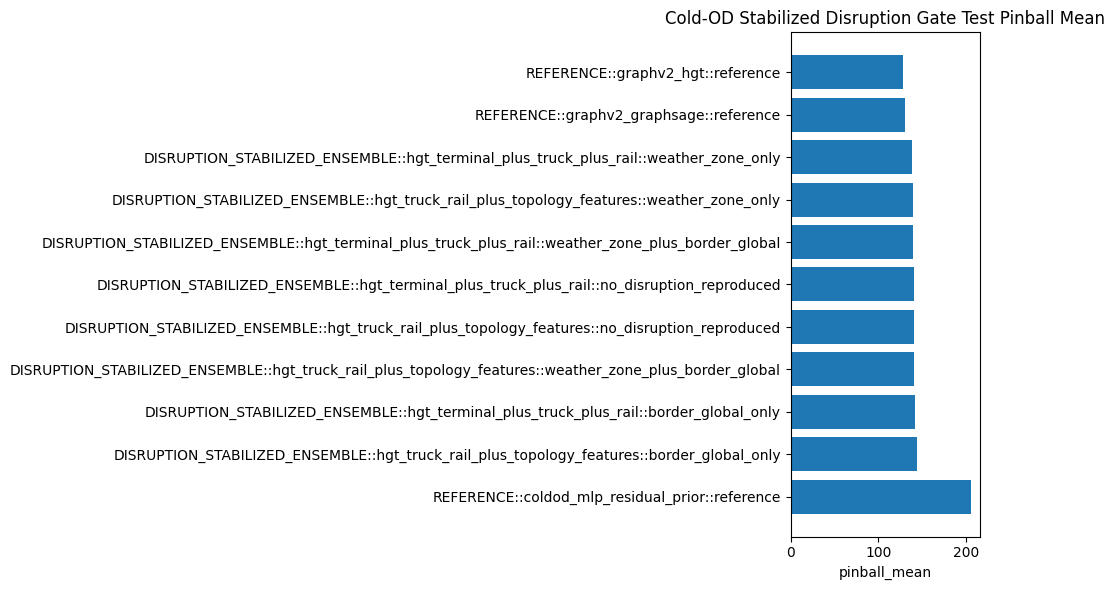

In [22]:

if MATPLOTLIB_AVAILABLE:
    top = leaderboard_test.head(25).copy()
    labels = top["source"].astype(str) + "::" + top["model"].astype(str) + "::" + top["disruption_group"].astype(str)
    plt.figure(figsize=(10, max(6, len(top) * 0.30)))
    plt.barh(labels[::-1], top["pinball_mean"].iloc[::-1])
    plt.xlabel("pinball_mean")
    plt.title("Cold-OD Stabilized Disruption Gate Test Pinball Mean")
    plt.tight_layout()
    plt.savefig(plots_dir / "disruption_gate_stabilized_leaderboard_pinball_mean.png", dpi=160)
    plt.show()


## 21. Save artifacts

In [23]:

paths_to_save = {
    "predictions_by_seed": output_dir / "predictions_disruption_gate_stabilized_by_seed.parquet",
    "predictions_seed_ensemble": output_dir / "predictions_disruption_gate_stabilized_seed_ensemble.parquet",
    "combined_predictions": output_dir / "combined_predictions_disruption_gate_stabilized.parquet",
    "metrics_by_seed": output_dir / "metrics_disruption_gate_stabilized_by_seed.csv",
    "metrics_seed_ensemble": output_dir / "metrics_disruption_gate_stabilized_seed_ensemble.csv",
    "combined_metrics": output_dir / "metrics_disruption_gate_stabilized_combined.csv",
    "leaderboard": output_dir / "leaderboard_test_disruption_gate_stabilized.csv",
    "checkpoint_summary": output_dir / "checkpoint_summary_disruption_gate_stabilized.csv",
    "history": output_dir / "training_history_disruption_gate_stabilized.csv",
    "paired_summary": output_dir / "paired_summary_disruption_gate_stabilized_test_only.csv",
    "paired_rows": output_dir / "paired_rows_disruption_gate_stabilized_test_only.parquet",
}

safe_to_parquet(graph_predictions_by_seed, paths_to_save["predictions_by_seed"])
safe_to_parquet(graph_predictions_seed_ensemble, paths_to_save["predictions_seed_ensemble"])
safe_to_parquet(combined_predictions, paths_to_save["combined_predictions"])
metrics_by_seed.to_csv(paths_to_save["metrics_by_seed"], index=False)
metrics_seed_ensemble.to_csv(paths_to_save["metrics_seed_ensemble"], index=False)
combined_metrics.to_csv(paths_to_save["combined_metrics"], index=False)
leaderboard_test.to_csv(paths_to_save["leaderboard"], index=False)
checkpoint_summary.to_csv(paths_to_save["checkpoint_summary"], index=False)
training_history.to_csv(paths_to_save["history"], index=False)
paired_summary.to_csv(paths_to_save["paired_summary"], index=False)
if not paired_rows.empty:
    safe_to_parquet(paired_rows, paths_to_save["paired_rows"])

for segment_col, table in segment_tables.items():
    table.to_csv(tables_dir / f"disruption_gate_stabilized_segment_summary__{segment_col}.csv", index=False)

run_config = {
    "notebook": "Disruption_Gate_Stabilization",
    "config": asdict(cfg),
    "target_scale": target_scale,
    "experiment_groups": experiment_groups,
    "topology_candidates": {k: {"edge_feature_mode": v["edge_feature_mode"], "use_terminals": v["use_terminals"], "relations": [str(r) for r in v["relations"]]} for k, v in TOPOLOGY_CANDIDATES.items()},
    "paths": {"output_dir": str(output_dir), "heterodata_path": str(paths.heterodata_path), "supervised_with_disruption_path": str(paths.supervised_with_disruption_path)},
    "package_versions": {"python": os.sys.version, "numpy": np.__version__, "pandas": pd.__version__, "torch": torch.__version__, "cuda_available": torch.cuda.is_available()},
}
write_json(run_config, output_dir / "run_config_disruption_gate_stabilized.json")
write_json({k: str(v) for k, v in paths_to_save.items()}, output_dir / "analysis_artifact_manifest_disruption_gate_stabilized.json")
print("Saved artifacts to", output_dir)


Saved artifacts to E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_disruption_gate_stabilization_v1_notebook\east_plus_gulf


## 22. Generate plain-text report

This report uses `to_string`, not `to_markdown`, so it does not require the optional `tabulate` package.


In [24]:

report_lines = []
report_lines.append("# Disruption Gate Stabilization Report")
report_lines.append("")
report_lines.append(f"Output directory: {output_dir}")
report_lines.append(f"Seeds: {list(cfg.seeds)}")
report_lines.append(f"Gate alpha init: {cfg.gate_alpha_init}")
report_lines.append("")
report_lines.append("## Disruption groups")
report_lines.append(feature_group_summary.to_string(index=False))
report_lines.append("")
report_lines.append("## Top test leaderboard rows")
report_lines.append(dataframe_to_text(leaderboard_test, ["rank", "source", "model", "disruption_group", "checkpoint_metric", "seed", "pinball_mean", "weighted_pinball_mean", "mae_q75", "iqr_mae", "stress_top10_mae_q75"], max_rows=30))
report_lines.append("")
report_lines.append("## Deduplicated references")
report_lines.append(reference_selection.to_string(index=False) if not reference_selection.empty else "No references available.")
report_lines.append("")
report_lines.append("## Paired summary")
report_lines.append(dataframe_to_text(paired_summary, ["reference_name", "candidate_model", "candidate_disruption_group", "candidate_seed", "n_rows", "mean_delta_pinball_mean_row", "win_rate_pinball_mean_row", "mean_delta_abs_error_q75", "win_rate_abs_error_q75"], max_rows=40))
report_lines.append("")
report_lines.append("## Interpretation guide")
report_lines.append("- no_disruption_reproduced should be close to the topology v3 baseline.")
report_lines.append("- weather_zone_only tests spatial NOAA weather exposure.")
report_lines.append("- border_global_only tests annual border stress calibration.")
report_lines.append("- weather_zone_plus_border_global tests the strongest compact combined disruption group.")
report_path = reports_dir / "disruption_gate_stabilization_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print("Wrote report:", report_path)


Wrote report: E:\NetworkOptimization\pythonProject1\Data\10_experiments\dcqhgt_disruption_gate_stabilization_v1_notebook\east_plus_gulf\reports\disruption_gate_stabilization_report.md


## 23. Final checklist

Check these points before interpreting the results:

1. `no_disruption_reproduced` should be close to topology v3.
2. Every ensemble row count should equal 1057 for the test split.
3. GraphV2 references should be deduplicated to one row per `row_id`.
4. Disruption groups should improve against their own no-disruption reproduced baseline.
5. Improvements should appear in q75, IQR, high-q75, high-IQR, or sparse segments.
